<a href="https://colab.research.google.com/github/ag22042008/data-Science-notebooks/blob/main/ann%2Bperceptronimplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [3]:
from sklearn.linear_model import Perceptron

In [4]:
from sklearn.metrics import  accuracy_score,classification_report,confusion_matrix

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [6]:
from sklearn.datasets import load_iris
iris=load_iris()

In [7]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [8]:
df=pd.concat([df,pd.Series(iris.target,name='species')],axis=1)

In [9]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [10]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df)

In [11]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 144.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
df['species'].value_counts()

,count
species,
0,50
1,50
2,50


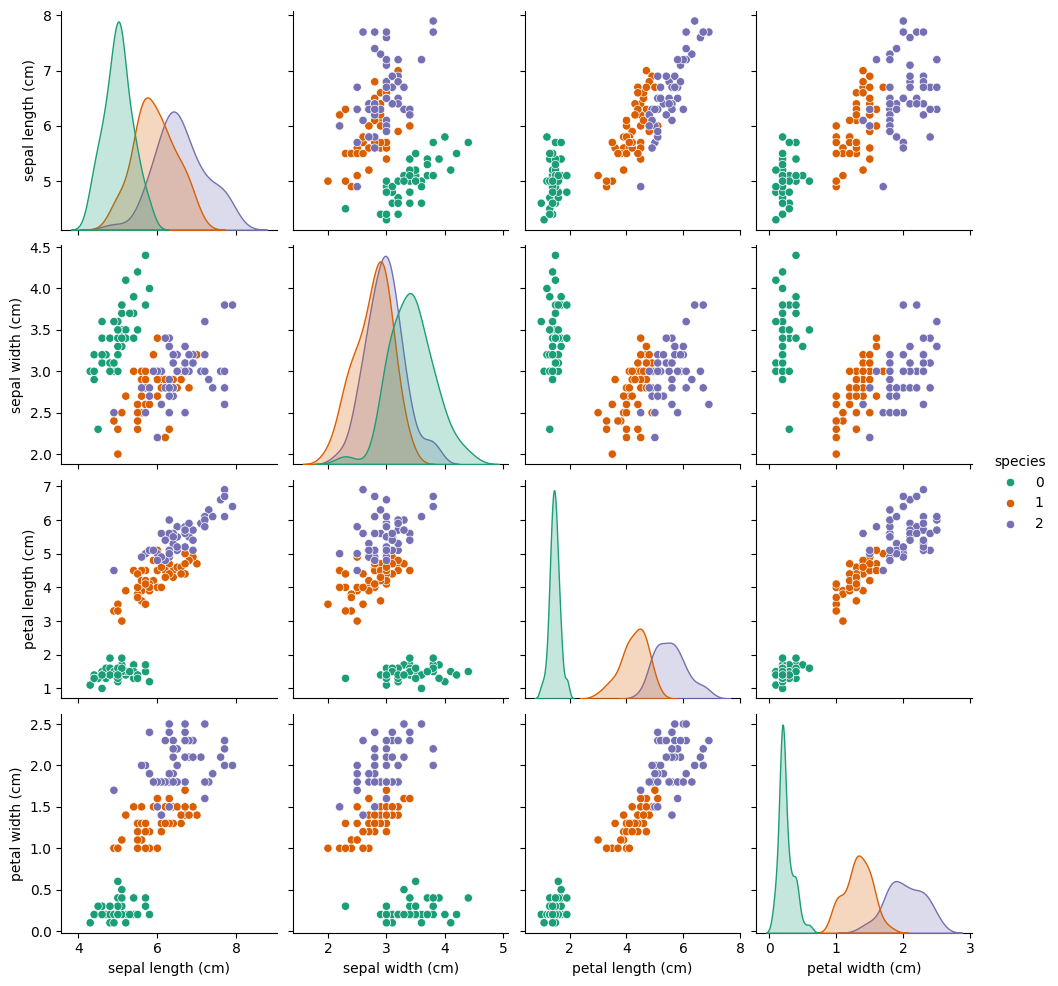

In [13]:
sns.pairplot(df,hue='species',palette='Dark2')

In [14]:
df=df.drop_duplicates()

In [15]:
df.shape

(149, 5)

In [16]:
X=df.drop('species',axis=1)

In [17]:
Y=df['species']

In [18]:
encoder=LabelEncoder()
Y=encoder.fit_transform(Y)

In [19]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [20]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [21]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [22]:
x_test=scaler.transform(x_test)

In [23]:
per=Perceptron(max_iter=1000,random_state=42)


In [24]:
per.fit(x_train,y_train)


Perceptron(random_state=42)

In [25]:
y_predict=per.predict(x_test)

In [26]:
y_predict

array([1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 2])

In [27]:
y_test

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 1, 0, 2, 0, 1, 2,
       0, 0, 1, 1, 2, 2, 2, 1])

In [28]:
accuracy_score(y_test,y_predict)

0.8333333333333334

In [29]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      0.60      0.71        10
           2       0.69      0.90      0.78        10

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.83        30
weighted avg       0.85      0.83      0.83        30



#ANN IMPLEMENTATION


In [30]:
Y_train=to_categorical(y_train,num_classes=3)

In [31]:
Y_test=to_categorical(y_test,num_classes=3)

In [32]:
Y_test

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [33]:
model2=Sequential([
    Dense(16,input_dim=4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])


In [34]:
model2.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [35]:
history=model2.fit(x_train,Y_train,epochs=100,batch_size=8,validation_split=0.2,shuffle=True,verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.5053 - loss: 0.9646 - val_accuracy: 0.5000 - val_loss: 0.9086
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5053 - loss: 0.8937 - val_accuracy: 0.5000 - val_loss: 0.8438
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5158 - loss: 0.8359 - val_accuracy: 0.4583 - val_loss: 0.7828
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5158 - loss: 0.7864 - val_accuracy: 0.4583 - val_loss: 0.7401
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5158 - loss: 0.7476 - val_accuracy: 0.5417 - val_loss: 0.7059
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6211 - loss: 0.7153 - val_accuracy: 0.7083 - val_loss: 0.6743
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7684 - loss: 0.6859 - val_accuracy: 0.7917 - val_loss: 0.6468
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8316 - loss: 0.6585 - val_accuracy: 0.

In [36]:
loss,acc=model2.evaluate(x_test,Y_test,verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9667 - loss: 0.1209


In [41]:
loss

0.12088281661272049

In [42]:
acc

0.9666666388511658

In [43]:
loss,acc=model2.evaluate(x_test,Y_test,verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9667 - loss: 0.1209


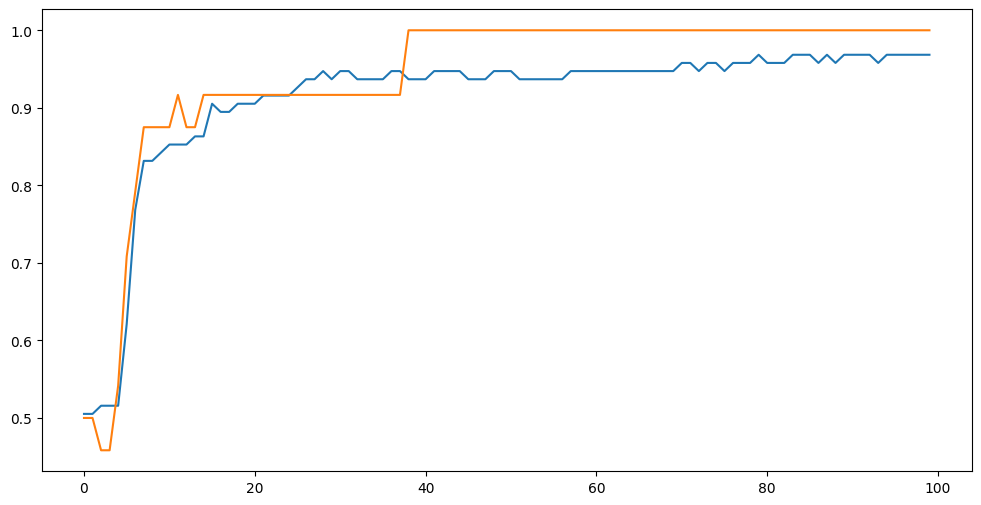

In [44]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'],label="train Acc")
plt.plot(history.history['val_accuracy'],label="val Acc")